# 04 DML Validation and Interpretation
## DML 검증 및 해석

FD-PLIV-DML 결과를 FE-IV 결과와 비교해, 가격 효과 추정이 모델 선택에 얼마나 민감한지 확인한다.
zip에 포함된 DML 결과는 own-sales 중심이므로, 이 노트북은 decomposition이 아니라 validation 중심으로 정리한다.


## Setup
### 설정


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables" / "model_results"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

CATEGORY_LABELS = {
    "cereal": "Cereal",
    "canned_soup": "Canned soup",
    "bottled_juices": "Bottled juices",
    "cookies": "Cookies",
}


In [2]:
def read_csv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def category_from_path(path):
    name = Path(path).name
    for category in CATEGORY_LABELS:
        if name.startswith(category):
            return category
    return None


def load_category_files(suffix):
    frames = []
    for path in sorted(TABLE_DIR.glob(f"*_only/*_{suffix}.csv")):
        frame = read_csv(path)
        if "category" not in frame.columns:
            frame["category"] = category_from_path(path)
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"No files matched suffix: {suffix}")
    return pd.concat(frames, ignore_index=True)


def add_category_label(frame):
    out = frame.copy()
    out["category_label"] = out["category"].map(CATEGORY_LABELS).fillna(out["category"])
    return out


def save_figure(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path


## FD-PLIV-DML estimates
### FD-PLIV-DML 추정치

Ridge와 LightGBM nuisance model을 사용한 partial IV 결과를 비교한다.


In [3]:
dml = load_category_files("fd_pliv_dml_own_sales_results")
dml = add_category_label(dml)

display(
    dml[["category_label", "spec", "learner", "coef_log_price_fd", "std_error", "t_stat", "n_obs", "mean_y_rmse", "mean_d_rmse", "mean_z_rmse"]]
    .sort_values(["category_label", "spec", "learner"])
)


,category_label,spec,learner,coef_log_price_fd,std_error,t_stat,n_obs,mean_y_rmse,mean_d_rmse,mean_z_rmse
1,Bottled juices,S1_ccount_only,LightGBM,-3.415545,0.021274,-160.547690,5833019,0.673008,0.074034,0.064569
0,Bottled juices,S1_ccount_only,Ridge,-3.414757,0.021303,-160.295339,5833019,0.675508,0.074039,0.064556
3,Bottled juices,S2_plus_deal,LightGBM,-2.755764,0.030085,-91.599829,5833019,0.634202,0.059100,0.061484
2,Bottled juices,S2_plus_deal,Ridge,-2.916820,0.026285,-110.970666,5833019,0.644516,0.063646,0.063776
5,Canned soup,S1_ccount_only,LightGBM,-2.980800,0.016497,-180.688254,6470630,0.668867,0.075521,0.056429
4,Canned soup,S1_ccount_only,Ridge,-2.980667,0.016528,-180.340844,6470630,0.673933,0.075529,0.056406
7,Canned soup,S2_plus_deal,LightGBM,-2.233059,0.028728,-77.730979,6470630,0.640162,0.054674,0.050506
6,Canned soup,S2_plus_deal,Ridge,-2.443011,0.021293,-114.735559,6470630,0.651241,0.063216,0.055032
9,Cereal,S1_ccount_only,LightGBM,-3.444474,0.013246,-260.036407,6145641,0.652511,0.094808,0.122372
8,Cereal,S1_ccount_only,Ridge,-3.443156,0.013254,-259.773659,6145641,0.657044,0.094842,0.122308


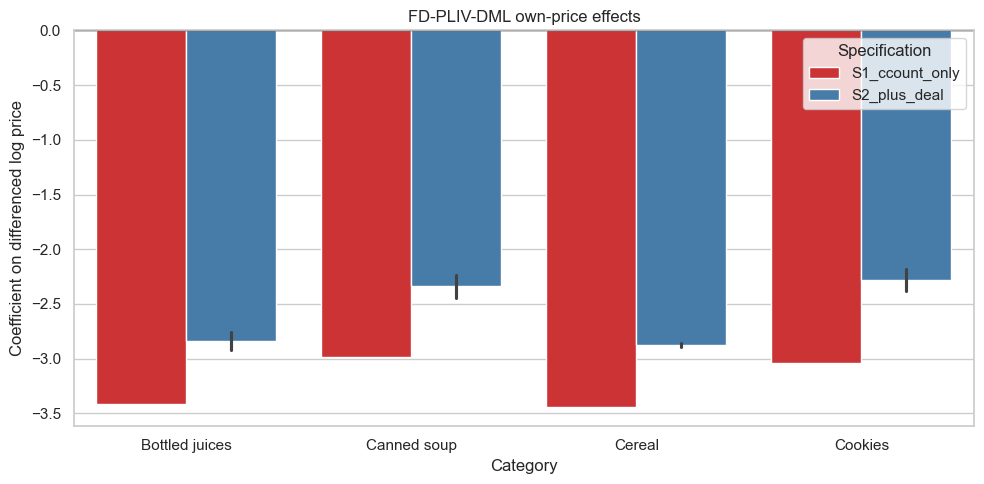

C:\Users\박동하\Documents\Codex\2026-05-16\files-mentioned-by-the-user-untitled48\dominicks-price-elasticity-iv-dml\outputs\figures\fd_pliv_dml_own_price_effects.png


In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(data=dml, x="category_label", y="coef_log_price_fd", hue="spec", palette="Set1")
plt.axhline(0, color="black", linewidth=1)
plt.title("FD-PLIV-DML own-price effects")
plt.xlabel("Category")
plt.ylabel("Coefficient on differenced log price")
plt.legend(title="Specification")
path = save_figure("fd_pliv_dml_own_price_effects.png")
plt.show()
print(path)


DML 결과는 네 카테고리 모두 강한 음의 가격 효과를 보인다.
다만 계수 크기는 FE-IV 기준 결과보다 훨씬 커서, 두 접근법은 같은 방향을 지지하지만 동일한 수치로 해석하기는 어렵다.


## FE-IV vs DML
### FE-IV와 DML 비교

가장 단순한 비교를 위해 FE-IV의 `B_ccount_only`와 DML의 `S1_ccount_only`를 나란히 둔다.


,category,category_label,coef,se,n_obs,model
4,bottled_juices,Bottled juices,-3.414757,0.021303,5833019,FD-PLIV-DML S1 Ridge
3,bottled_juices,Bottled juices,-0.189112,0.111633,5963789,FE-IV B_ccount_only
5,canned_soup,Canned soup,-2.980667,0.016528,6470630,FD-PLIV-DML S1 Ridge
0,canned_soup,Canned soup,-0.284672,0.035025,6704250,FE-IV B_ccount_only
6,cereal,Cereal,-3.443156,0.013254,6145641,FD-PLIV-DML S1 Ridge
1,cereal,Cereal,-1.155855,0.043671,6319195,FE-IV B_ccount_only
7,cookies,Cookies,-3.042693,0.024003,12562079,FD-PLIV-DML S1 Ridge
2,cookies,Cookies,-1.716031,0.063463,12858058,FE-IV B_ccount_only


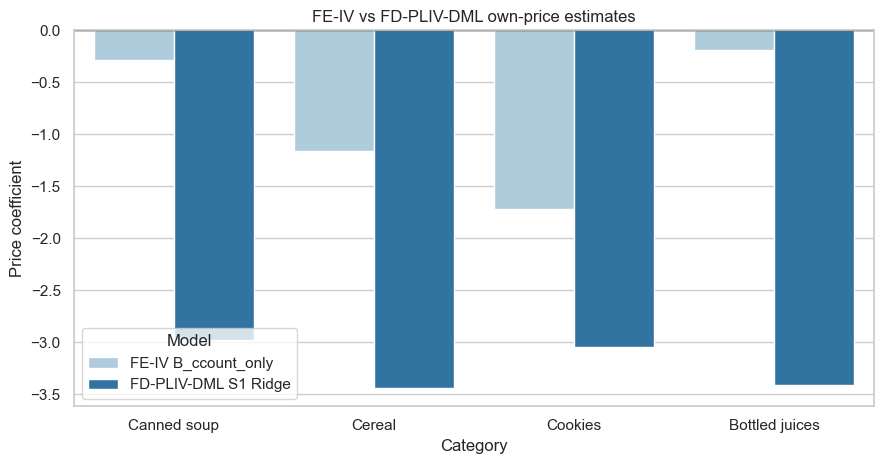

C:\Users\박동하\Documents\Codex\2026-05-16\files-mentioned-by-the-user-untitled48\dominicks-price-elasticity-iv-dml\outputs\figures\fe_iv_vs_dml_comparison.png


In [5]:
fe = load_category_files("fe_iv_own_sales_control_ladder")
fe = add_category_label(fe)
fe_main = fe[(fe["spec"] == "B_ccount_only") & (fe["outcome_name"] == "own_sales")].copy()
fe_main = fe_main.sort_values("std_error").drop_duplicates(["category"], keep="first")
fe_main = fe_main[["category", "category_label", "coef_log_price", "std_error", "n_obs"]].rename(
    columns={"coef_log_price": "coef", "std_error": "se"}
)
fe_main["model"] = "FE-IV B_ccount_only"

dml_main = dml[(dml["spec"] == "S1_ccount_only") & (dml["learner"] == "Ridge")].copy()
dml_main = dml_main[["category", "category_label", "coef_log_price_fd", "std_error", "n_obs"]].rename(
    columns={"coef_log_price_fd": "coef", "std_error": "se"}
)
dml_main["model"] = "FD-PLIV-DML S1 Ridge"

comparison = pd.concat([fe_main, dml_main], ignore_index=True)
display(comparison.sort_values(["category_label", "model"]))

plt.figure(figsize=(9, 4.8))
sns.barplot(data=comparison, x="category_label", y="coef", hue="model", palette="Paired")
plt.axhline(0, color="black", linewidth=1)
plt.title("FE-IV vs FD-PLIV-DML own-price estimates")
plt.xlabel("Category")
plt.ylabel("Price coefficient")
plt.legend(title="Model")
path = save_figure("fe_iv_vs_dml_comparison.png")
plt.show()
print(path)


두 방법 모두 가격 상승과 판매 감소의 방향성은 일치한다.
포트폴리오 해석에서는 “가격 효과가 있다”는 방향성은 강하게 말할 수 있지만, 절대 탄력성 크기는 specification과 식별 전략에 민감하다고 제한하는 편이 안전하다.


## Portfolio takeaway
### 포트폴리오 결론

이 프로젝트는 대용량 retail scanner 데이터에서 가격 내생성을 통제하려는 계량 분석이다.
최종 메시지는 단일 모델의 성능이 아니라, FE-IV, dynamic lag, FD-PLIV-DML을 통해 가격 효과의 방향성과 민감도를 함께 검증했다는 점이다.
